In [1]:
from numpy.polynomial import chebyshev as C
import numpy as np
import scipy as sp
import scipy.stats
from colossus.cosmology import cosmology
cosmology.setCosmology('planck15')
from colossus.lss import mass_function as mf
import glob
import numexpr as ne
from numba import jit
import time

In [2]:
z = 1.0
bins = 0.005

files = [f.split('a')[1].split('.d')[0] for f in glob.glob('ssfrs/ssfr_a*.dat')]
ssfr_a_list = np.array([float(a) for a in files])
ssfr_mass_list = np.array([np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,0] for f in files])
ssfr_list = [np.loadtxt("ssfrs/ssfr_a"+f+".dat")[:,1] for f in files]

files = [f.split('a')[1].split('.d')[0] for f in glob.glob('smfs/smf_a*.dat')]
smf_a_list = np.array([float(a) for a in files])
smf_mass_list = np.array([np.loadtxt("smfs/smf_a"+f+".dat")[:,0] for f in files])
smf_list = [np.loadtxt("smfs/smf_a"+f+".dat")[:,1] for f in files]

param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))

a = 1.0/(1.0+z)

StellBins = np.linspace(3.0, 12.5, int((12.5 - 3.0) / bins))

closest_a = np.argmin(np.abs(ssfr_a_list - a))

#### extract ssfr
ssfrs = np.array(ssfr_list[closest_a])
nonzero = (ssfrs != 0)
masses = np.array(ssfr_mass_list[closest_a])
SSFRs = 10**np.interp(StellBins, masses[nonzero], np.log10(ssfrs[nonzero]))

#### extrapolate out to high M*
slope = (np.log10(ssfrs[nonzero][-1]) - np.log10(ssfrs[nonzero][-2])) / (masses[nonzero][-1] - masses[nonzero][-2])
inter = np.log10(ssfrs[nonzero][-1]) - slope * masses[nonzero][-1]
gtzero = (StellBins >= masses[nonzero][-1])
SSFRs[gtzero] = 10**(StellBins[gtzero]*slope + inter)

#### extrapolate out to low M*
slope = (np.log10(ssfrs[1]) - np.log10(ssfrs[0])) / (masses[1] - masses[0])
inter = np.log10(ssfrs[0]) - slope * masses[0]
ltavail = (StellBins < masses[0])
SSFRs[ltavail] = 10**(StellBins[ltavail]*slope + inter)


### extract smf
closest_a = np.argmin(np.abs(smf_a_list - a))
smf = np.array(smf_list[closest_a])
nonzero = (smf != 0)
masses = np.array(smf_mass_list[closest_a])
dNdlogMstar = 10**np.interp(StellBins, masses[nonzero], np.log10(smf[nonzero]))

#### extrapolate out to high M*
slope = (np.log10(smf[nonzero][-1]) - np.log10(smf[nonzero][-2])) / (masses[nonzero][-1] - masses[nonzero][-2])
inter = np.log10(smf[nonzero][-1]) - slope * masses[nonzero][-1]
dNdlogMstar[gtzero] = 10**(StellBins[gtzero]*slope + inter)

#### extrapolate out to low M*
slope = (np.log10(smf[1]) - np.log10(smf[0])) / (masses[1] - masses[0])
inter = np.log10(smf[0]) - slope * masses[0]
dNdlogMstar[ltavail] = 10**(StellBins[ltavail]*slope + inter)

dNdlnMstar = dNdlogMstar/np.log(10)

In [3]:
def Shen_fit_uncer(z, lums): ###best fit data from Shen+2020

    def get_params():
        rand_params = np.zeros((NUM, len(params)))
        ind = 0
        for p in params:
            i = np.random.randint(1,3,NUM)
            rand_params[:,ind][i == 1] = param_list[ind][0] + np.abs(np.random.normal(0, param_list[ind][1], size = len(i[i==1])))
            rand_params[:,ind][i == 2] = param_list[ind][0] - np.abs(np.random.normal(0, param_list[ind][2], size = len(i[i==2])))
            ind += 1
        return rand_params

    def shen_func(p):
        L = lums
        a0, a1, a2, b0, b1, b2, c0, c1, c2, d0, d1 = p
        zr = 2.0
        zfrac = (1 + z)/(1 + zr)
        g1 = C.chebval(1 + z, [a0, a1, a2])
        g2 = 2*b0/(zfrac**b1 + zfrac **b2)
        logLs = 2*c0/(zfrac**c1 + zfrac**c2)
        logPhis = C.chebval(1 + z, [d0, d1])
        Lfrac = 10**L / 10**logLs
        Phibol = 10**logPhis/(Lfrac**g1 + Lfrac**g2)
        return np.log10(Phibol)

    params = {'a0':[0.8569, 0.0247, 0.0253], 'a1':[-0.2614, 0.0162, 0.0164], 'a2':[0.0200,0.0011,0.0011],\
        'b0':[2.5375, 0.0177, 0.0187], 'b1':[-1.0425,0.0164, 0.0182], 'b2':[1.1201, 0.0199, 0.0207],\
        'c0':[13.0088, 0.0090, 0.0091], 'c1':[-0.5759, 0.0018, 0.0020], 'c2':[0.4554, 0.0028, 0.0027],\
        'd0':[-3.5426, 0.0235, 0.0209], 'd1':[-0.3936, 0.0070, 0.0073]}
    param_list = np.array([params[i] for i in params])

    NUM = int(1e4)

    rand_params = get_params()
    ys = np.apply_along_axis(shen_func, 1, rand_params).T
    ya = shen_func(param_list[:,0])

    fracs = sp.stats.norm.cdf([-2, -1, 0, 1, 2])
    percs = np.percentile(ys, 100*fracs, axis=1)

    std_ave = np.std(ys, axis=1)
    std_blw = ya-percs[1,:]
    std_abv = percs[3,:]-ya
    
    zr = 2.0
    zfrac = (1 + z)/(1 + zr)
    logLs = 2*params['c0'][0]/(zfrac**params['c1'][0] + zfrac**params['c2'][0])

    return ya, std_ave, std_abv, std_blw, logLs

In [4]:
@jit(nopython=True) 
def get_QLF(L, bins = 0.005, logMstar0 = None, slope_low = None, norm_from_local = None, norm_local = 8.2, approx_local = True, presig = None, postsig = None):
    
    norm = [11, norm_local]

    logMstar = StellBins
    BHBins = logMstar * 0
    slopes = logMstar * 0

    logMbh0 = logMstar0 + norm[1] - norm[0] - norm_from_local
    my_norm = [logMstar0, logMbh0]
    post_params = [1, logMbh0 - logMstar0]
    pre_params = [slope_low, my_norm[1] - my_norm[0] * slope_low]

    post = (logMstar > logMstar0)
    pre = (logMstar <= logMstar0)
    Ms = 10**logMstar
    Ms0 = 10**logMstar0
    Mbh0 = 10**logMbh0
    beta = post_params[0]
    alpha = 10**norm[1] / 10**(norm[0]*beta)

    Mbh = Mbh0 + alpha * Ms[post]**(beta-1) * (Ms[post] - Ms0)
    BHBins[post] = np.log10(Mbh)
    slopes[post] = alpha * beta * Ms[post]**beta / Mbh

    BHBins[pre] = logMstar[pre] * pre_params[0] + pre_params[1]
    slopes[pre] = pre_params[0]

    ## SSFR are in yr^-1
    SBHARs = slopes * (SSFRs / 3.154e7) ## s^-1
    MdotBH = SBHARs * (10**BHBins * 2e33) ## g/s

    lnxsig_list = StellBins * 0
    lnxsig_list[pre] = presig
    lnxsig_list[post] = postsig
    ### start transition at the M*crit value
    critpoint = np.argmin(np.abs(StellBins - logMstar0))
    ### end transistion 0.5 dex after that value
    endtran = np.argmin(np.abs(StellBins - (logMstar0 + 0.5)))
    lintrans = np.linspace(presig, postsig, len(lnxsig_list[critpoint-1:endtran]))
    lnxsig_list[critpoint-1:endtran] = lintrans
    
    MU_LIST = []
    SIG_LIST = []
    for lnxsig, mdotbh in zip(lnxsig_list, MdotBH):
        mu_lnx = -0.5 * lnxsig**2
        mu_lnmdotbh = mu_lnx + np.log(mdotbh) #g/s
        MU_LIST.append(mu_lnmdotbh)
        SIG_LIST.append(lnxsig)
    MU_LIST = np.array(MU_LIST)
    SIG_LIST = np.array(SIG_LIST)
        
    lnMdotbh_list = (np.asarray(L) + np.log10(3.9e33)) * np.log(10) - np.log(0.1*2.99e10**2)

    intvals = []
    for mdot in lnMdotbh_list:
        y = ( 1/np.sqrt(2.0 * np.pi * SIG_LIST*SIG_LIST) ) * np.exp( -(mdot - MU_LIST)**2.0 / (2.0 * SIG_LIST*SIG_LIST) )
        intvals.append(y * dNdlnMstar * (StellBins[1] - StellBins[0]) * np.log(10))

    dNdlnL = []
    for val in intvals:
        totval = 0.0 
        for n in val:
            totval = totval + n
        dNdlnL.append(totval)

    dNdlogL = np.array(dNdlnL) * np.log(10)
    return dNdlogL


In [5]:
input_d = {'logMstar0':10.0, 'slope_low':0.4, 'norm_from_local':3.0, 'norm_local':8.23, 'presig':3.0, 'postsig':2.0}
L = np.linspace(8.95, 14.95, 100)
start = time.time()
test_QLF = get_QLF(L, **input_d)
end = time.time()

print(f'With compilation time. {end-start}')


With compilation time. 3.344939947128296


In [6]:
print('Without compilation time.')
%timeit test_QLF = get_QLF(L, **input_d)


Without compilation time.
3.09 ms ± 145 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


24.7 ms ± 2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


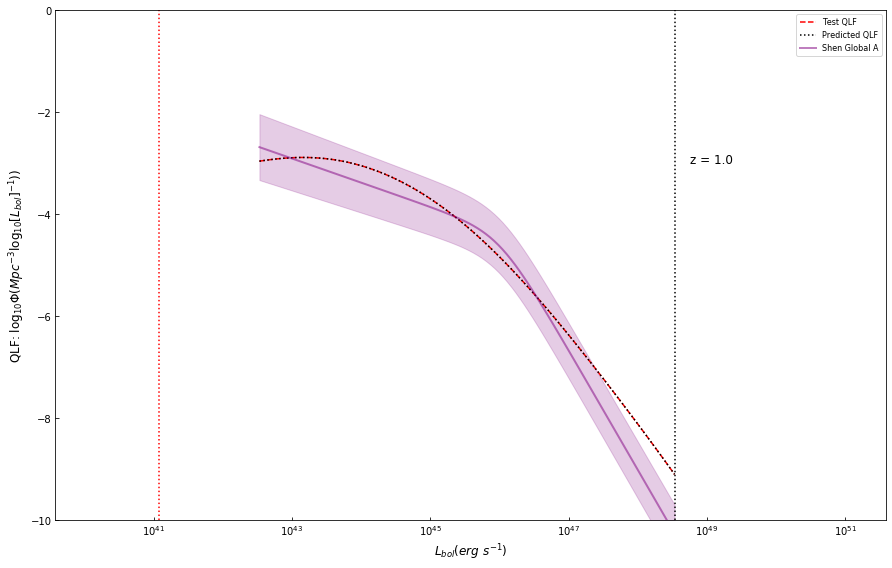

In [10]:
from functions import *
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,1,figsize=(12.5,8))

lumsp = 10**L*3.8e33

critlw = 1
mainlw = 1.5
sublw = 1.25

ax.plot(lumsp, np.log10(test_QLF), c='r', linestyle='dashed', lw=mainlw, label = 'Test QLF')


qlf = QLF(1, 0.005)
qlf.get_Mbh(input_d['logMstar0'], input_d['slope_low'], input_d['norm_from_local'], approx_local=True, norm_local = input_d['norm_local'])
%timeit qlf.get_dNdlnL(L, [input_d['presig'], input_d['postsig']])

ax.plot(lumsp, np.log10(qlf.dNdlogL), c='k', label = 'Predicted QLF',linestyle='dotted')   


lumsshen = L
xshen = 10**lumsshen*3.8e33
dens, stanave, stanab, stanb, _ = Shen_fit_uncer(1.0, lumsshen)
ax.plot(xshen, dens, label='Shen Global A',c='purple',lw=2,alpha = 0.5)
ax.fill_between(xshen, dens-stanab-0.5, dens+stanb+0.5, color='purple', alpha=.2)
ax.axvline(10**7.5*3.8e33,c='r',linestyle='dotted')
ax.axvline(10**14.95*3.8e33,c='k',linestyle='dotted')
    
    
    
ax.axis([10**6*3.8e33,10**18*3.8e33,-10,0])
ax.set_xlabel(r'$L_{bol} (erg\ s^{-1})$', fontsize=12)
ax.set_ylabel(r'QLF: $\log_{10} \Phi (Mpc^{-3} \log_{10} [L_{bol}]^{-1})$)', fontsize =12)
ax.text(10**48.75,-3,'z = 1.0', fontsize = 12)
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', labelsize=10, direction='in')
ax.legend(fontsize = 8)

    

plt.tight_layout()


